### Figure S4. Systemic antagonism of NMDARs disrupt learning from rewarded actions

Import packages and figure setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import os
import zipfile
import warnings
import fed3bandit as f3b
import copy
from pandas.api.types import CategoricalDtype
from scipy.stats import ttest_rel, ttest_ind
from osfclient import OSF

warnings.filterwarnings("ignore")

plt.rcParams.update({
    'font.size': 32, 
    'figure.autolayout': True, 
    'lines.linewidth': 2, 
    'axes.spines.top': False, 
    'axes.spines.right': False
    })

cat_size_order = CategoricalDtype(["Sal", "MK801"], ordered=True)

Fetching data from OSF and extracting it

In [4]:
# Create output directory
output_dir = "osf_downloads"
os.makedirs(output_dir, exist_ok=True)

# Connect to OSF
osf = OSF()
project = osf.project('stk2r')
storage = project.storage('osfstorage')

# Set up folder name with data
target_filename = 'Figure_S4_data.zip'

# Download zip file with data
for file in storage.files:
    if file.name == target_filename:
        output_path = os.path.join(output_dir, file.name)
        with open(output_path, 'wb') as f:
            file.write_to(f)
        print(f"Downloaded: {file.name} to {output_path}")
        break
else:
    print(f"File '{target_filename}' not found in OSF storage.")

#Set up 
zip_path = 'osf_downloads/Figure_S4_data.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(output_dir)

print(f"Extracted all files to {output_dir}")

100%|██████████| 310k/310k [00:00<00:00, 2.06Mbytes/s]

Downloaded: Figure_S4_data.zip to osf_downloads\Figure_S4_data.zip
Extracted all files to osf_downloads


Formatting the data for analysis and adding injection times

In [5]:
fileloc = os.path.join(os.getcwd(), "osf_downloads", "Figure_S4_data")

saline_data = {
    "saline_1": {
        "C48M3": pd.read_csv(fileloc + "/saline_C48M3_022723.csv"),
        "C50F1": pd.read_csv(fileloc + "/saline_C50F1_022723.csv"),
        "C50F5": pd.read_csv(fileloc + "/saline_C50F5_022723.csv"),
        "C116F2": pd.read_csv(fileloc + "/saline_C116F2_022723.csv"),
        "C116F4": pd.read_csv(fileloc + "/saline_C116F4_022723.csv")
        },
    "saline_2": {
        "C75M1": pd.read_csv(fileloc + "/saline_C75M1_021723_2.csv"),
        "C75M2": pd.read_csv(fileloc + "/saline_C75M2_021723_2.csv"),
        "C75M3": pd.read_csv(fileloc + "/saline_C75M3_021723_2.csv"),
        "C116AF1": pd.read_csv(fileloc + "/saline_C116AF1_021723_2.csv"),
        "C116AF3": pd.read_csv(fileloc + "/saline_C116AF3_021723_2.csv"),
        "C116AF5": pd.read_csv(fileloc + "/saline_C116AF5_021723_2.csv"),
        }
    }

saline_injectiontimes = {
    "saline_1": datetime.datetime(2023,2,27,19,15),
    "saline_2": datetime.datetime(2023,2,20,17,45)
    }

#
mk801_data = {
    "mk801_1": {
        "C75M1": pd.read_csv(fileloc + "/mk801_C75M1_022723.csv"),
        "C75M2": pd.read_csv(fileloc + "/mk801_C75M2_022723.csv"),
        "C75M3": pd.read_csv(fileloc + "/mk801_C75M3_022723.csv"),
        "C116AF1": pd.read_csv(fileloc + "/mk801_C116AF1_022723.csv"),
        "C116AF3": pd.read_csv(fileloc + "/mk801_C116AF3_022723.csv"),
        "C116AF5": pd.read_csv(fileloc+ "/mk801_C116AF5_022723.csv")
        },
    "mk801_2": {
        "C48M3": pd.read_csv(fileloc + "/mk801_C48M3_021723_2.csv"),
        "C50F1": pd.read_csv(fileloc + "/mk801_C50F1_021723_2.csv"),
        "C50F5": pd.read_csv(fileloc + "/mk801_C50F5_021723_2.csv"),
        "C116F2": pd.read_csv(fileloc + "/mk801_C116F2_021723_2.csv"),
        "C116F4": pd.read_csv(fileloc + "/mk801_C116F4_021723_2.csv")
        }
    }

mk801_injectiontimes = {
    "mk801_1": datetime.datetime(2023,2,27,19,15),
    "mk801_2": datetime.datetime(2023,2,20,17,45)
    }



Data Pre-processing

In [ ]:
#
post_hours = 8

p_saline_data = {}
for session in saline_data:
    c_session = saline_data[session]
    p_session = {}
    for mouse in c_session:
        f_mouse = f3b.filter_data(c_session[mouse])
        s_mouse = f_mouse[np.logical_and(f_mouse.iloc[:,0] > saline_injectiontimes[session], 
                                         f_mouse.iloc[:,0] < (saline_injectiontimes[session] + datetime.timedelta(hours=post_hours)))]
        p_session[mouse] = s_mouse
    
    p_saline_data[session] = p_session

#
p_mk801_data = {}
for session in mk801_data:
    c_session = mk801_data[session]
    p_session = {}
    for mouse in c_session:
        f_mouse = f3b.filter_data(c_session[mouse])
        s_mouse = f_mouse[np.logical_and(f_mouse.iloc[:,0] > mk801_injectiontimes[session], 
                                         f_mouse.iloc[:,0] < (mk801_injectiontimes[session] + datetime.timedelta(hours=post_hours)))]
        p_session[mouse] = s_mouse
    
    p_mk801_data[session] = p_session

print("All files have been successfully filtered and pre-processed")

Processing saline_1
Processing saline_2
Processing mk801_1
Processing mk801_2
All files have been successfully filtered and pre-processed


Sample behavior after saline or MK801 infusion. Panel S4B

(-9.950000000000001, 208.95, -0.05, 1.05)

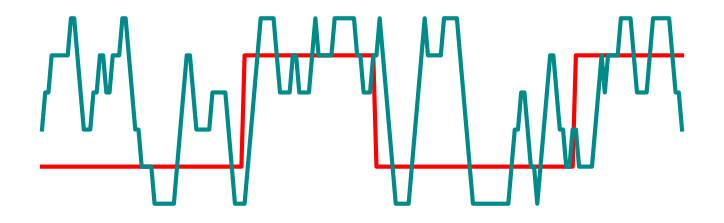

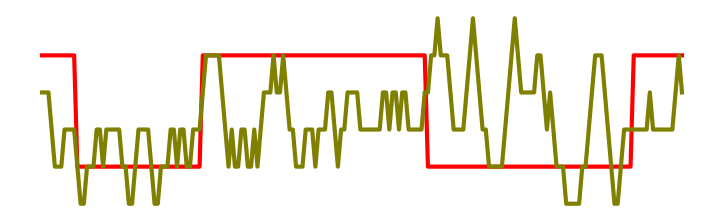

In [8]:
c50f5_sal = p_saline_data["saline_1"]["C50F5"].iloc[:205,:]
sal_probs = c50f5_sal["Session_type"].iloc[5:] / 100
sal_choices = f3b.binned_paction(c50f5_sal, 5)

c50f5_mk801 = p_mk801_data["mk801_2"]["C50F5"].iloc[:205,:]
mk801_probs = c50f5_mk801["Session_type"].iloc[5:] / 100
mk801_choices = f3b.binned_paction(c50f5_mk801, 5)

fig, ax = plt.subplots(figsize=(8,3))
ax.plot(np.arange(len(sal_probs)),sal_probs, c='red', linewidth=3)
ax.plot(np.arange(len(sal_probs)), sal_choices, c='darkcyan', linewidth=3)
plt.axis("off")
#plt.savefig(figure_dir + "\\example_sal.eps", bbox_inches="tight")

fig, ax = plt.subplots(figsize=(8,3))
ax.plot(np.arange(len(mk801_probs)),mk801_probs, c='red', linewidth=3)
ax.plot(np.arange(len(mk801_probs)), mk801_choices, c='olive', linewidth=3)
plt.axis("off")

Calculation of pokes, pellets, pokes per pellet, win-stay, and lose-shift metrics.
For documentation and source code of FED3Bandit package, which is used to calculate metrics, please see:

FED3Bandit package documentation: https://fed3bandit.readthedocs.io/en/latest/analysis/fed3live_api.html

FED3Bandit package source code:  https://github.com/AlexLM96/fed3bandit/blob/main/fed3bandit/fed3bandit/fed3bandit.py


In [9]:
# Metrics of the saline group
saline_pellets = {}
saline_pokes = {}
saline_ws = {}
saline_ls = {}
for session in p_saline_data:
    #Load data
    c_session = p_saline_data[session]
    
    #Calculate metrics
    c_session_pellets = {mouse: [f3b.count_pellets(c_session[mouse])] for mouse in c_session}
    c_session_pokes = {mouse: [f3b.count_pokes(c_session[mouse])] for mouse in c_session}
    c_session_ws = {mouse: [f3b.win_stay(c_session[mouse])] for mouse in c_session}
    c_session_ls = {mouse: [f3b.lose_shift(c_session[mouse])] for mouse in c_session}

    saline_pellets = saline_pellets | c_session_pellets
    saline_pokes = saline_pokes | c_session_pokes
    saline_ws = saline_ws | c_session_ws
    saline_ls = saline_ls | c_session_ls
    
saline_pellets = pd.DataFrame(saline_pellets).T
saline_pokes = pd.DataFrame(saline_pokes).T
saline_ws = pd.DataFrame(saline_ws).T
saline_ls = pd.DataFrame(saline_ls).T
    
# Metrics of the MK801 group
mk801_pellets = {}
mk801_pokes = {}
mk801_ws = {}
mk801_ls = {}
for session in p_mk801_data:
    #Load data
    c_session = p_mk801_data[session]
    
    #Calculate metrics
    c_session_pellets = {mouse: [f3b.count_pellets(c_session[mouse])] for mouse in c_session}
    c_session_pokes = {mouse: [f3b.count_pokes(c_session[mouse])] for mouse in c_session}
    c_session_ws = {mouse: [f3b.win_stay(c_session[mouse])] for mouse in c_session}
    c_session_ls = {mouse: [f3b.lose_shift(c_session[mouse])] for mouse in c_session}

    mk801_pellets = mk801_pellets | c_session_pellets
    mk801_pokes = mk801_pokes | c_session_pokes
    mk801_ws = mk801_ws | c_session_ws
    mk801_ls = mk801_ls | c_session_ls
    
mk801_pellets = pd.DataFrame(mk801_pellets).T
mk801_pokes = pd.DataFrame(mk801_pokes).T
mk801_ws = pd.DataFrame(mk801_ws).T
mk801_ls = pd.DataFrame(mk801_ls).T

print("All metrics have been successfully calculated")

All metrics have been successfully calculated


Concatenating saline and mk801 groups and preparing for plotting.

In [10]:
# Pellets
all_pellets = pd.concat([saline_pellets, mk801_pellets], axis=1).reset_index()
all_pellets.columns = ["Mouse", "Sal", "MK801"]
m_all_pellets = pd.melt(all_pellets, id_vars="Mouse")
m_all_pellets["variable"] = m_all_pellets["variable"].astype(cat_size_order)
m_all_pellets = m_all_pellets.sort_values(by="variable")

# Pokes
all_pokes = pd.concat([saline_pokes, mk801_pokes], axis=1).reset_index()
all_pokes.columns = ["Mouse", "Sal", "MK801"]
m_all_pokes = pd.melt(all_pokes, id_vars="Mouse")
m_all_pokes["variable"] = m_all_pokes["variable"].astype(cat_size_order)
m_all_pokes = m_all_pokes.sort_values(by="variable")

#Win-stay
all_ws = pd.concat([saline_ws, mk801_ws], axis=1).reset_index()
all_ws.columns = ["Mouse", "Sal", "MK801"]
m_all_ws = pd.melt(all_ws, id_vars="Mouse")
m_all_ws["variable"] = m_all_ws["variable"].astype(cat_size_order)
m_all_ws = m_all_ws.sort_values(by="variable")

#Lose-shift
all_ls = pd.concat([saline_ls, mk801_ls], axis=1).reset_index()
all_ls.columns = ["Mouse", "Sal", "MK801"]
m_all_ls = pd.melt(all_ls, id_vars="Mouse")
m_all_ls["variable"] = m_all_ls["variable"].astype(cat_size_order)
m_all_ls = m_all_ls.sort_values(by="variable")

print("All metrics have been reformatted and are ready for plotting")

All metrics have been reformatted and are ready for plotting


Pokes plot and statistics (Panel S4C)

TtestResult(statistic=1.409632973659523, pvalue=0.18898150944241884, df=10)


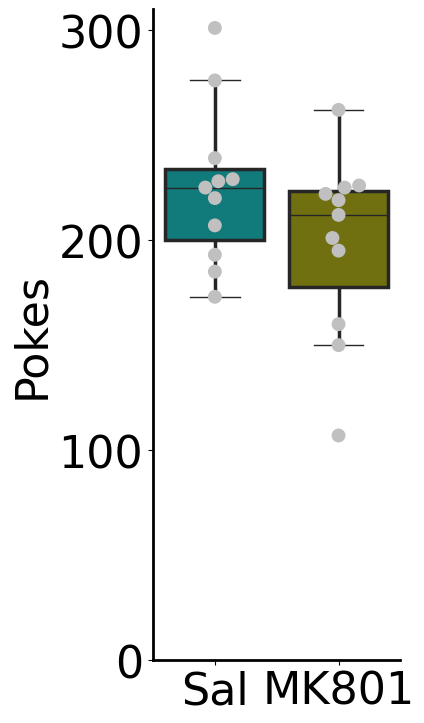

In [26]:
fig, ax = plt.subplots(figsize=(5, 8))
sns.boxplot(x="variable", y="value", data=m_all_pokes, palette=[
            "darkcyan", "olive"], boxprops={"linewidth": 2.5}, whiskerprops={"linewidth": 2.5})
sns.swarmplot(x="variable", y="value", data=m_all_pokes,
              palette=["silver", "silver"], s=10)
ax.set_ylabel("Pokes")
ax.set_xlabel("")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.set_ylim(0,310)
ax.set_yticks(np.arange(0,310,100))
sns.despine()

# Run independent ttest
mk801_pokes_ttest = ttest_rel(m_all_pokes["value"][m_all_pokes["variable"]== "Sal"], 
                                m_all_pokes["value"][m_all_pokes["variable"] == "MK801"], nan_policy="omit")

print(mk801_pokes_ttest)

Pellets plot and statistics (Panel S4D)

TtestResult(statistic=2.1447242994045106, pvalue=0.05757452051648293, df=10)


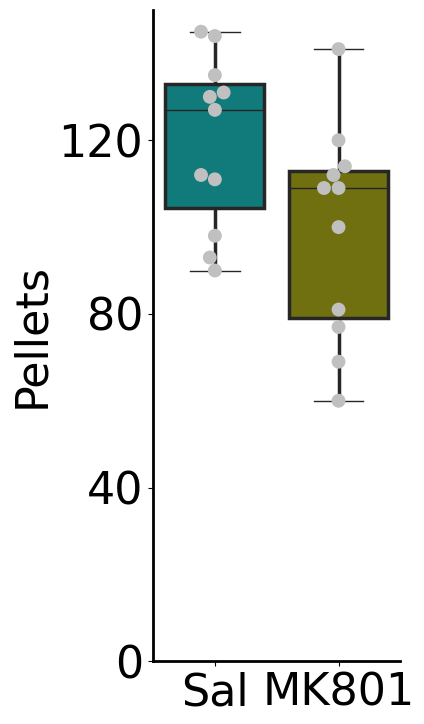

In [29]:
fig, ax = plt.subplots(figsize=(5, 8))
sns.boxplot(x="variable", y="value", data=m_all_pellets, palette=[
            "darkcyan", "olive", "salmon"], boxprops={"linewidth": 2.5}, whiskerprops={"linewidth": 2.5})
sns.swarmplot(x="variable", y="value", data=m_all_pellets, palette=["silver", "silver", "silver"], s=10)
ax.set_ylabel("Pellets")
ax.set_xlabel("")
sns.despine()
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.set_ylim(0,150)
ax.set_yticks(np.arange(0,160,40))

# Run independent ttest
mk801_pellets_ttest = ttest_rel(m_all_pellets["value"][m_all_pellets["variable"]== "Sal"], 
                                m_all_pellets["value"][m_all_pellets["variable"] == "MK801"], nan_policy="omit")

print(mk801_pellets_ttest)

Calculation of Block change peri-event histogram

In [ ]:
#Block change peri-event histogram for MK801 group
m_sal_pehs = {}
for session in p_saline_data:
    c_session = p_saline_data[session]
    c_pehs = {mouse: f3b.reversal_peh(c_session[mouse], (-10,11)).mean(axis=0) for mouse in c_session}
    c_pehs_df = pd.DataFrame(c_pehs)
    c_pehs_df = c_pehs_df.assign(Trial=np.arange(-10,11), Treatment="Sal")
    m_c_pehs = pd.melt(c_pehs_df, id_vars=["Trial", "Treatment"])
    m_sal_pehs[session] = m_c_pehs

m_sal_pehs = pd.concat(m_sal_pehs.values())

#Block change peri-event histogram for MK801 group
m_mk801_pehs = {}
for session in p_mk801_data:
    c_session = p_mk801_data[session]
    c_pehs = {mouse: f3b.reversal_peh(c_session[mouse], (-10,11)).mean(axis=0) for mouse in c_session}
    c_pehs_df = pd.DataFrame(c_pehs)
    c_pehs_df = c_pehs_df.assign(Trial=np.arange(-10,11), Treatment="MK801")
    m_c_pehs = pd.melt(c_pehs_df, id_vars=["Trial", "Treatment"])
    m_mk801_pehs[session] = m_c_pehs

m_mk801_pehs = pd.concat(m_mk801_pehs.values())

# Here we pool both groups
m_all_pehs = pd.concat([m_sal_pehs, m_mk801_pehs])

print("All pehs were succesfully calculated")

All peh were succesfully calculated


Plot of block change peri-event histogram. Panel S4E

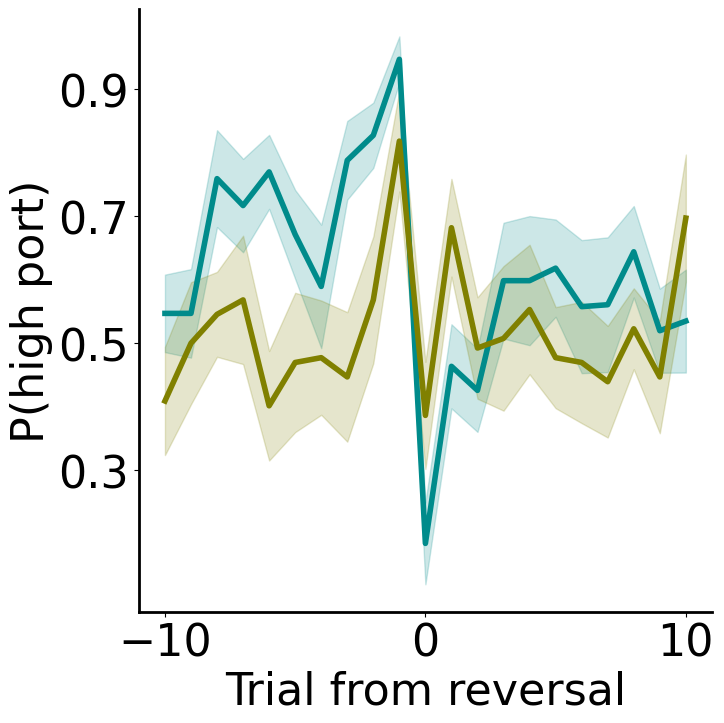

In [30]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.lineplot(x="Trial", y="value", hue="Treatment", data=m_all_pehs, linewidth=4, palette=["darkcyan", "olive"], errorbar="se", legend=False)
ax.set_ylabel("P(high port)")
ax.set_xlabel("Trial from reversal")
ax.set_yticks(np.arange(0.3, 1, 0.2))
sns.despine()
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

TtestResult(statistic=3.461046776283531, pvalue=0.006112030621468016, df=10)


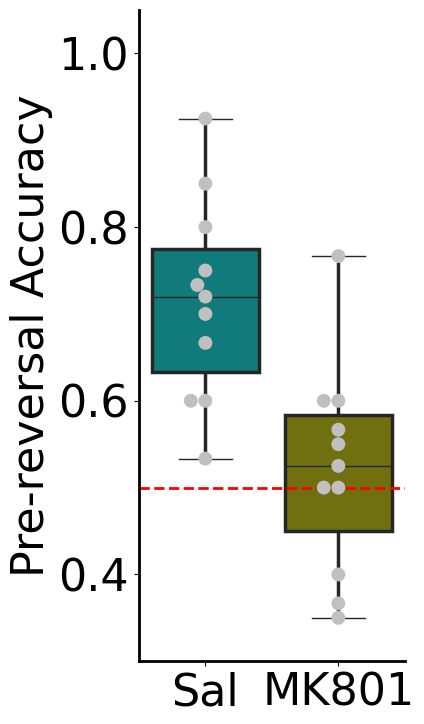

In [32]:
"""Finding the average accuracy prior to the block change."""
all_pre_pehs = m_all_pehs[m_all_pehs["Trial"] < 0]
mean_pre_pehs = all_pre_pehs.groupby(["Treatment", "variable"]).mean().reset_index()
mean_pre_pehs["Treatment"] = mean_pre_pehs["Treatment"].astype(cat_size_order)
mean_pre_pehs = mean_pre_pehs.sort_values(by="Treatment")

#Plot of the average accuracy. Panel 4F Right
fig, ax = plt.subplots(figsize=(5, 8))
sns.boxplot(x="Treatment", y="value", data=mean_pre_pehs, palette=[
            "darkcyan", "olive"], boxprops={"linewidth": 2.5}, whiskerprops={"linewidth": 2.5})
sns.swarmplot(x="Treatment", y="value", data=mean_pre_pehs, palette=["silver", "silver"], s=10)
ax.axhline(0.5, color="red", linestyle="--")
ax.set_ylabel("Pre-reversal Accuracy")
ax.set_xlabel("")
ax.set_yticks(np.arange(0.4, 1.2, 0.2))
ax.set_ylim(0.3,1.05)
sns.despine()
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

#Statistical test
mk801_rev_ttest = ttest_rel(mean_pre_pehs["value"][mean_pre_pehs["Treatment"]== "Sal"], mean_pre_pehs["value"][mean_pre_pehs["Treatment"] == "MK801"])
print(mk801_rev_ttest)

Plot and statistics of win-stay behavior. Panel S4F

TtestResult(statistic=5.374662137300003, pvalue=2.9228354687318827e-05, df=20.0)


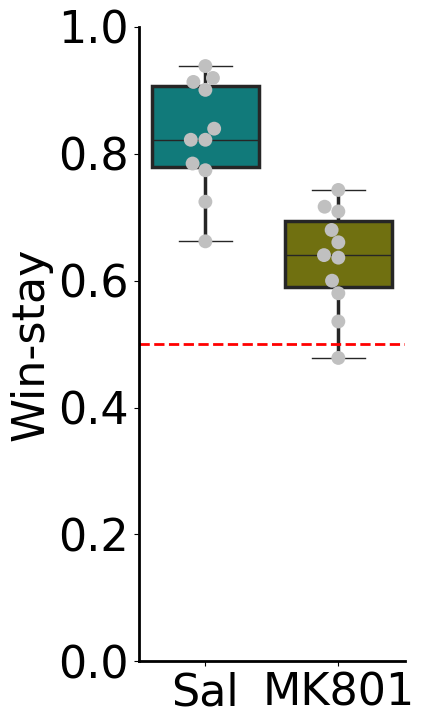

In [23]:
fig, ax = plt.subplots(figsize=(5, 8))
sns.boxplot(x="variable", y="value", data=m_all_ws, palette=[
            "darkcyan", "olive"], boxprops={"linewidth": 2.5}, whiskerprops={"linewidth": 2.5})
sns.swarmplot(x="variable", y="value", data=m_all_ws, palette=["silver", "silver"], s=10)
ax.set_ylabel("Win-stay")
ax.set_xlabel("")
ax.set_ylim(0,1)
ax.axhline(0.5, color="red", linestyle="--")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
sns.despine()

#Statistical test
mk801_ws_ttest = ttest_ind(m_all_ws["value"][m_all_ws["variable"]== "Sal"], m_all_ws["value"][m_all_ws["variable"] == "MK801"], nan_policy="omit")
print(mk801_ws_ttest)

Fitting the logistic regression to test influence of past rewarded trials on behavior.


In [24]:
saline_pcoeffs = {}
for session in p_saline_data:
    c_session = p_saline_data[session]
    c_session_sidep = {mouse: f3b.side_prewards(c_session[mouse]) for mouse in c_session}
    c_session_preX = {mouse: f3b.create_X(c_session[mouse], c_session_sidep[mouse], 5)
                      for mouse in c_session_sidep}
    c_session_pcoeffs = {mouse: f3b.logit_regr(c_session_preX[mouse]).params for mouse in c_session_preX}
    saline_pcoeffs = saline_pcoeffs | c_session_pcoeffs
    
saline_pcoeffs = pd.DataFrame(saline_pcoeffs)
saline_pcoeffs = saline_pcoeffs.assign(Treatment="Sal", Trial=np.flip(np.arange(-5, 0, 1)))
m_saline_pcoeffs = pd.melt(saline_pcoeffs, id_vars=["Treatment", "Trial"])

# Count of ws after mk801 injections
mk801_pcoeffs = {}
for session in p_mk801_data:
    print(session)
    c_session = p_mk801_data[session]
    c_session_sidep = {mouse: f3b.side_prewards(c_session[mouse]) for mouse in c_session}
    c_session_preX = {mouse: f3b.create_X(c_session[mouse], c_session_sidep[mouse], 5)
                      for mouse in c_session_sidep}
    c_session_pcoeffs = {mouse: f3b.logit_regr(c_session_preX[mouse]).params for mouse in c_session_preX}
    mk801_pcoeffs = mk801_pcoeffs | c_session_pcoeffs
    
mk801_pcoeffs = pd.DataFrame(mk801_pcoeffs)
mk801_pcoeffs = mk801_pcoeffs.assign(Treatment="MK801", Trial=np.flip(np.arange(-5, 0, 1)))
m_mk801_pcoeffs = pd.melt(mk801_pcoeffs, id_vars=["Treatment", "Trial"])

m_all_pcoeffs = pd.concat([m_saline_pcoeffs, m_mk801_pcoeffs])

print("Logistic regression for wins was succesffully calculated")

Optimization terminated successfully.
         Current function value: 0.571807
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.411557
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.464574
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.613461
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.528623
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.534456
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.541910
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.452007
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.656749
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.601500
  

Plot and statistics of regression coefficients. Panel S4G

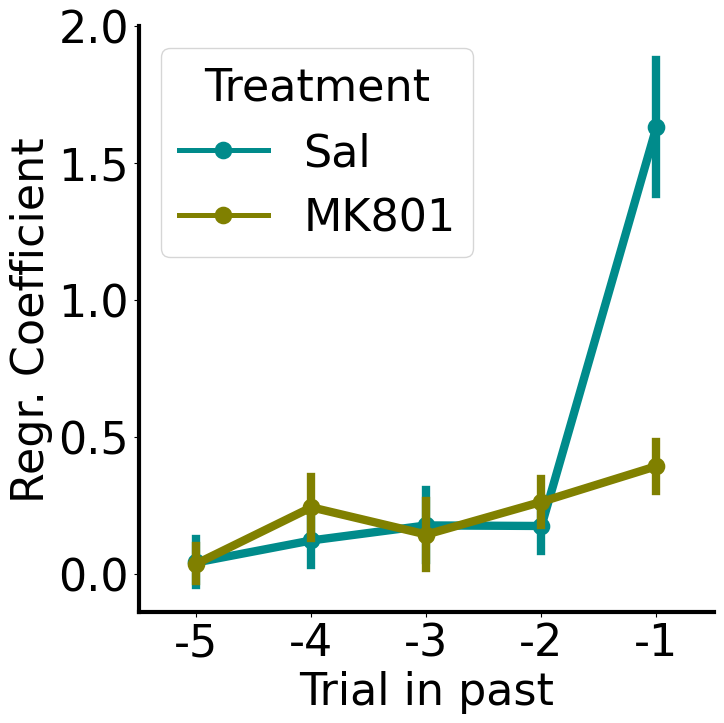

In [25]:
#Panel 4I Left. Plot of regressor coefficients
fig, ax = plt.subplots(figsize=(8, 8))
sns.pointplot(x="Trial", y="value", hue="Treatment", data=m_all_pcoeffs,
              palette=["darkcyan", "olive"], errwidth=3, errorbar="se", markersize=10)
for line in ax.lines:
    line.set_linewidth(6)
ax.set_xlabel("Trial in past")
ax.set_ylabel("Regr. Coefficient")
ax.set_yticks(np.arange(0,2.01,0.5))
ax.spines["left"].set_linewidth(3)
ax.spines["bottom"].set_linewidth(3)
sns.despine()

TtestResult(statistic=3.927968034533221, pvalue=0.0028295392897445585, df=10)


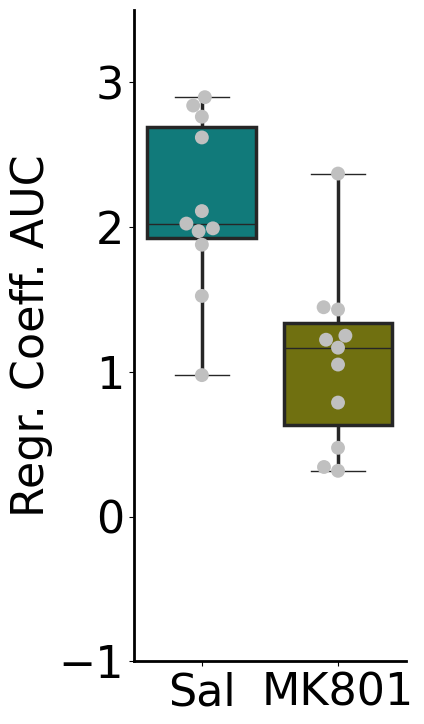

In [34]:
#Plotting of sum of regressor coefficients in both groups
all_paucs = m_all_pcoeffs.groupby(by=["Treatment", "variable"]).sum().reset_index()
all_paucs["Treatment"] = all_paucs["Treatment"].astype(cat_size_order)
all_paucs = all_paucs.sort_values(by="Treatment")

fig, ax = plt.subplots(figsize=(5, 8))
sns.boxplot(x="Treatment", y="value", data=all_paucs, palette=[
            "darkcyan", "olive"], boxprops={"linewidth": 2.5}, whiskerprops={"linewidth": 2.5})
sns.swarmplot(x="Treatment", y="value", data=all_paucs,
              palette=["silver", "silver"], s=10)
ax.set_ylabel("Regr. Coeff. AUC")
ax.set_xlabel("")
ax.set_yticks(np.arange(-1,4,1))
ax.set_ylim(-1,3.5)
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
sns.despine()

#Statistical test
mk801_pauc_ttest = ttest_rel(all_paucs["value"][all_paucs["Treatment"]== "Sal"], all_paucs["value"][all_paucs["Treatment"] == "MK801"])
print(mk801_pauc_ttest)

Plotting lose-shift. Figure S4I

TtestResult(statistic=-0.5013505807174642, pvalue=0.621598084674447, df=20.0)


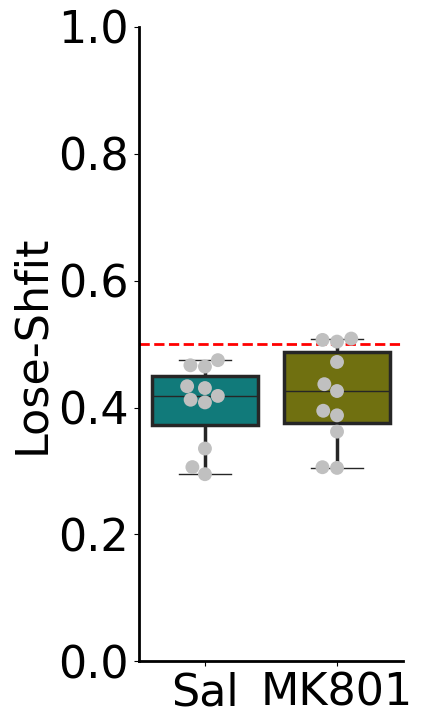

In [36]:
fig, ax = plt.subplots(figsize=(5, 8))
sns.boxplot(x="variable", y="value", data=m_all_ls, palette=[
            "darkcyan", "olive"], boxprops={"linewidth": 2.5}, whiskerprops={"linewidth": 2.5})
sns.swarmplot(x="variable", y="value", data=m_all_ls, palette=["silver", "silver"], s=10)
ax.set_ylabel("Lose-Shfit")
ax.set_xlabel("")
ax.set_ylim(0,1)
ax.axhline(0.5, color="red", linestyle="--")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
sns.despine()

#Statistical test
mk801_ls_ttest = ttest_ind(m_all_ls["value"][m_all_ls["variable"]== "Sal"], m_all_ls["value"][m_all_ls["variable"] == "MK801"], nan_policy="omit")
print(mk801_ls_ttest)

Fitting the logistic regression to test influence of past unrewarded trials on behavior.


In [39]:
saline_ncoeffs = {}
for session in p_saline_data:
    c_session = p_saline_data[session]
    c_session_siden = {mouse: f3b.side_nrewards(c_session[mouse]) for mouse in c_session}
    c_session_prenX = {mouse: f3b.create_X(c_session[mouse], c_session_siden[mouse], 5)
                      for mouse in c_session_siden}
    c_session_ncoeffs = {mouse: f3b.logit_regr(c_session_prenX[mouse]).params for mouse in c_session_prenX}
    saline_ncoeffs = saline_ncoeffs | c_session_ncoeffs
    
saline_ncoeffs = pd.DataFrame(saline_ncoeffs)
saline_ncoeffs = saline_ncoeffs.assign(Treatment="Sal", Trial=np.flip(np.arange(-5, 0, 1)))
m_saline_ncoeffs = pd.melt(saline_ncoeffs, id_vars=["Treatment", "Trial"])

# Count of ws after mk801 injections
mk801_ncoeffs = {}
for session in p_mk801_data:
    print(session)
    c_session = p_mk801_data[session]
    c_session_siden = {mouse: f3b.side_nrewards(c_session[mouse]) for mouse in c_session}
    c_session_prenX = {mouse: f3b.create_X(c_session[mouse], c_session_siden[mouse], 5)
                      for mouse in c_session_siden}
    c_session_ncoeffs = {mouse: f3b.logit_regr(c_session_prenX[mouse]).params for mouse in c_session_prenX}
    mk801_ncoeffs = mk801_ncoeffs | c_session_ncoeffs
    
mk801_ncoeffs = pd.DataFrame(mk801_ncoeffs)
mk801_ncoeffs = mk801_ncoeffs.assign(Treatment="MK801", Trial=np.flip(np.arange(-5, 0, 1)))
m_mk801_ncoeffs = pd.melt(mk801_ncoeffs, id_vars=["Treatment", "Trial"])

m_all_ncoeffs = pd.concat([m_saline_ncoeffs, m_mk801_ncoeffs])

all_naucs = m_all_ncoeffs.groupby(by=["Treatment", "variable"]).sum().reset_index()
all_naucs["Treatment"] = all_naucs["Treatment"].astype(cat_size_order)
all_naucs = all_naucs.sort_values(by="Treatment")

print("Logistic regression for wins was succesffully calculated")

Optimization terminated successfully.
         Current function value: 0.639056
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.664580
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.692023
         Iterations 3
Optimization terminated successfully.
         Current function value: 0.680903
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.606205
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.688484
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.675126
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.681407
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.683156
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.607068
  

Plot and statistics of regression coefficients for unrewarded trials. Figure S4J. 

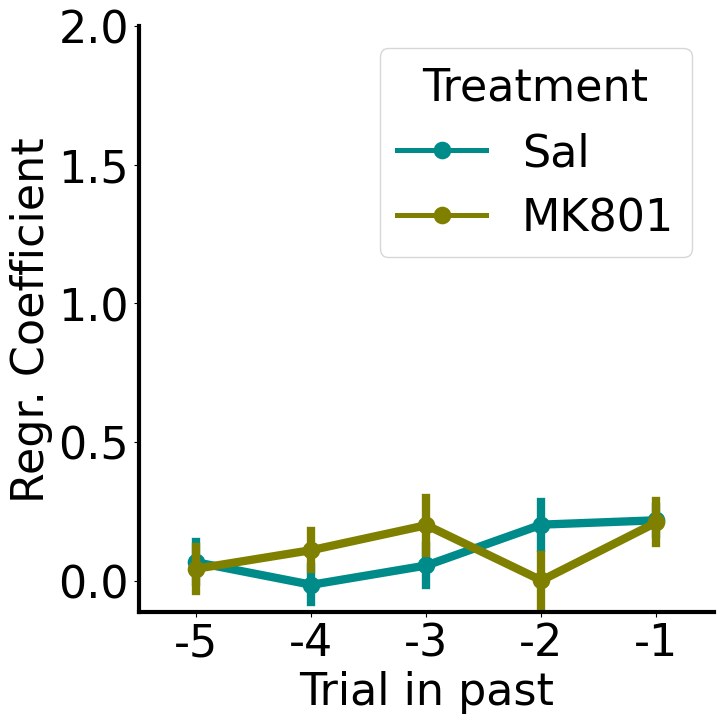

In [40]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.pointplot(x="Trial", y="value", hue="Treatment", data=m_all_ncoeffs,
              palette=["darkcyan", "olive"], errwidth=3, errorbar="se", markersize=10)
for line in ax.lines:
    line.set_linewidth(6)
ax.set_xlabel("Trial in past")
ax.set_ylabel("Regr. Coefficient")
ax.set_yticks(np.arange(0,2.01,0.5))
ax.spines["left"].set_linewidth(3)
ax.spines["bottom"].set_linewidth(3)
sns.despine()

TtestResult(statistic=-0.10960667799943102, pvalue=0.9138136420715091, df=20.0)


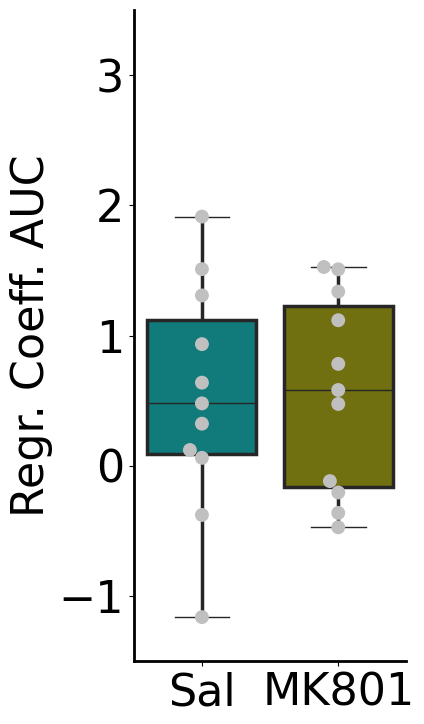

In [43]:
fig, ax = plt.subplots(figsize=(5, 8))
sns.boxplot(x="Treatment", y="value", data=all_naucs, palette=[
            "darkcyan", "olive"], boxprops={"linewidth": 2.5}, whiskerprops={"linewidth": 2.5})
sns.swarmplot(x="Treatment", y="value", data=all_naucs, palette=["silver", "silver"], s=10)
ax.set_ylabel("Regr. Coeff. AUC")
ax.set_xlabel("")
ax.set_yticks(np.arange(-1,4,1))
ax.set_ylim(-1.5,3.5)
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
sns.despine()

# Independent ttest
mk801_nauc_ttest = ttest_ind(all_naucs["value"][all_naucs["Treatment"]== "Sal"], all_naucs["value"][all_naucs["Treatment"] == "MK801"])
print(mk801_nauc_ttest)